In [22]:
!pip install gymnasium
!pip install minigrid
!pip install torch torchvision
!pip install imageio

In [23]:
import gymnasium as gym
import minigrid
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import imageio
from collections import deque
from IPython.display import Image

env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array", max_episode_steps=100)
obs, info = env.reset()

obs_shape = obs["image"].shape
state_size = np.prod(obs_shape)

action_size = env.action_space.n

In [24]:
class DQN(nn.Module):
  def __init__(self, state_size, action_size):
    super().__init__()

    self.net = nn.Sequential(
        nn.Linear(state_size,128),
        nn.ReLU(),
        nn.Linear(128,128),
        nn.ReLU(),
        nn.Linear(128, action_size)
    )
  
  def forward(self,x):
    return self.net(x)

In [25]:
class ReplayBuffer:
    
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
        
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state,action,reward,next_state,done))
        
    def sample(self,batch_size):
        batch = random.sample(self.buffer,batch_size)
        states,actions,rewards,next_states,dones = zip(*batch)
        return states,actions,rewards,next_states,dones
    
    def __len__(self):
        return len(self.buffer)

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

policy_net = DQN(state_size,action_size).to(device)
target_net = DQN(state_size,action_size).to(device)

target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(),lr=1e-3)

buffer = ReplayBuffer(50000)

cuda


In [27]:
gamma = 0.99
batch_size = 64
epsilon = 1.0          # start fully random
epsilon_min = 0.05
epsilon_decay = 0.9995  # was 0.997 — decays much more slowly, hits min ~ep 1500

episodes = 2000
target_update = 10     # was 20 — sync target net more often

In [28]:
import time
start_time = time.time()

for episode in range(episodes):
    obs, inf = env.reset()
    # FIX 1: /255.0 (float) instead of //255 (integer division that zeros most values)
    state = obs["image"].flatten().astype(np.float32) / 255.0

    done = False

    while not done:
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                s = torch.FloatTensor(state).unsqueeze(0).to(device)
                action = policy_net(s).argmax().item()

        next_obs, reward, done, truncated, info = env.step(action)
        # FIX 1 again: consistent /255.0
        next_state = next_obs["image"].flatten().astype(np.float32) / 255.0

        buffer.push(state, action, reward, next_state, done or truncated)

        state = next_state

        if len(buffer) > batch_size:
            states, actions, rewards, next_states, dones = buffer.sample(batch_size)

            # FIX 2: np.array() before torch conversion — kills the slow tensor warning
            states      = torch.FloatTensor(np.array(states)).to(device)
            actions     = torch.LongTensor(np.array(actions)).unsqueeze(1).to(device)
            rewards     = torch.FloatTensor(np.array(rewards)).to(device)
            next_states = torch.FloatTensor(np.array(next_states)).to(device)
            dones       = torch.FloatTensor(np.array(dones)).to(device)

            q_values = policy_net(states).gather(1, actions).squeeze()

            with torch.no_grad():
                next_q_values = target_net(next_states).max(1)[0]
            target = rewards + gamma * next_q_values * (1 - dones)

            loss = nn.MSELoss()(q_values, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    epsilon = max(epsilon_min, epsilon_decay * epsilon)

    if episode % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if episode % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"Episode: {episode} | epsilon: {epsilon:.4f} | elapsed: {elapsed:.1f} min")
    elif episode % 10 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"Episode: {episode} |] elapsed: {elapsed:.1f} min")

total = (time.time() - start_time) / 60
print(f"\nDone! Total time: {total:.1f} minutes")

Episode: 0 | epsilon: 0.9995 | elapsed: 0.0 min
Episode: 10 |] elapsed: 1.4 min
Episode: 20 |] elapsed: 1.8 min
Episode: 30 |] elapsed: 2.4 min
Episode: 40 |] elapsed: 2.6 min
Episode: 50 |] elapsed: 3.0 min
Episode: 60 |] elapsed: 3.3 min
Episode: 70 |] elapsed: 3.7 min
Episode: 80 |] elapsed: 4.0 min
Episode: 90 |] elapsed: 4.5 min
Episode: 100 | epsilon: 0.9507 | elapsed: 4.9 min
Episode: 110 |] elapsed: 5.4 min
Episode: 120 |] elapsed: 5.7 min
Episode: 130 |] elapsed: 6.1 min
Episode: 140 |] elapsed: 6.5 min
Episode: 150 |] elapsed: 6.9 min
Episode: 160 |] elapsed: 7.2 min
Episode: 170 |] elapsed: 7.4 min
Episode: 180 |] elapsed: 8.0 min
Episode: 190 |] elapsed: 8.5 min
Episode: 200 | epsilon: 0.9044 | elapsed: 9.0 min
Episode: 210 |] elapsed: 9.6 min
Episode: 220 |] elapsed: 10.0 min
Episode: 230 |] elapsed: 10.5 min
Episode: 240 |] elapsed: 11.1 min
Episode: 250 |] elapsed: 11.5 min
Episode: 260 |] elapsed: 12.1 min
Episode: 270 |] elapsed: 12.8 min
Episode: 280 |] elapsed: 13.5 

In [30]:
# Fresh env just for rendering
render_env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array", max_episode_steps=100)

frames = []

obs, _ = render_env.reset()
state = obs["image"].flatten().astype(np.float32) / 255.0

done = False
truncated = False

while not done and not truncated:
    frame = render_env.render()
    frames.append(frame)

    with torch.no_grad():
        s = torch.FloatTensor(state).unsqueeze(0).to(device)
        action = policy_net(s).argmax().item()

    next_obs, reward, done, truncated, _ = render_env.step(action)
    state = next_obs["image"].flatten().astype(np.float32) / 255.0

frames.append(render_env.render())
render_env.close()

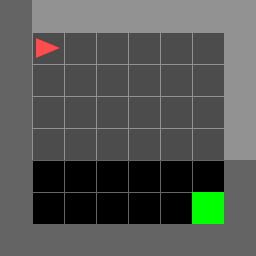

In [32]:
imageio.mimsave("dqn_navigation.gif",frames,fps=5)
Image("dqn_navigation.gif")